Physics short options

# S32: Chaos, Random Processes, and Predictability

### Lecture 1: Overview


Milan Klöwer (milan.kloewer@physics.ox.ac.uk)

Adapted from the 2024 notebook by Hannah Christensen.

## Getting started

This is a [Jupyter Notebook](https://jupyter.org/) using a Python 3 kernel. There are many ways to install Jupyter Notebooks, we have used the following

- Install [miniforge](https://github.com/conda-forge/miniforge) as a Python distribution
- Install [jupyter notebook](https://jupyter.org/install)
- Launch a notebooks server and open this notebook

Alternatives include: [Google colab](https://colab.research.google.com/) (requires Google account), conda or miniconda distributions (licensed though), Linux/macOS systems come with `python` and the package manager `pip` (but not the package manager conda or [mamba](https://mamba.readthedocs.io/en/latest/)).

In all cases you can just search the internet for "install python and jupyter" -- if there are problems we can discuss them after Lecture 2 (Thu week 1).

In [1]:
import numpy as np   # outside the notebook, in a shell, install e.g. `conda install numpy`
np.random.rand()     # just checking we can draw a random number from [0, 1)

0.7857513072157284

## Chaos in one variable: The Logistic Map
#### A biological example

Budworms breed rapidly, but also exhaust their food supply, so the population in year $i+1$ is given by 
$$ x_{i+1} = r x_i (1 - x_i) $$
where $x_i$ is the population in year $i$, $r$ is the growth rate in the absence of food constraints, and $x_i$ is normalised such that if $x_i = 1$, the budworms eat all their food supply and the population collapses to zero. Apparently this is not a great model of budworm population dynamics as you for example, also should introduce a term to describe birds eating the budworms. But it illustrates how a simple discrete equation with one variable can exhibit chaotic behaviour.

In python we can define a function with `def`, function name, arguments, function body and return value, in this case

In [2]:
def logistic_map(xᵢ, r):
    return r * xᵢ * (1 - xᵢ)

As this function would only return the next value $x_{i+1}$ given $x_i$ and the growth parameter $r$ we define another function that just loops over $N$ time steps and stores every iteration of the logistic map in a numpy array

In [3]:
def logistic_map_timeseries(x0, r, N):
    x = np.zeros(N)                      # allocate vector with zeros
    x[0] = x0                            # set initial condition
    for i in range(N-1):                 # skip initial condition step
        x[i+1] = logistic_map(x[i], r)

    return x

# now create a time series with
# - x0, initial condition
# - r, growth parameter
# - n, number of time steps (years)
x = logistic_map_timeseries(x0=0.01, r=2.9, N=64)
x

array([0.01      , 0.02871   , 0.08086863, 0.2155538 , 0.49036205,
       0.72473062, 0.57853883, 0.70711179, 0.60060365, 0.69564883,
       0.61399246, 0.68731659, 0.62324624, 0.68095006, 0.63004552,
       0.67595567, 0.63521485, 0.67197914, 0.63922721, 0.66878578,
       0.64238295, 0.66620858, 0.64488666, 0.66412279, 0.64688476,
       0.66243211, 0.64848585, 0.66106067, 0.64977244, 0.65994783,
       0.65080841, 0.65904479, 0.65164379, 0.65831207, 0.65231814,
       0.65771764, 0.65286293, 0.65723548, 0.65330331, 0.65684448,
       0.65365945, 0.65652744, 0.65394756, 0.65627043, 0.6541807 ,
       0.6560621 , 0.6543694 , 0.65589326, 0.65452215, 0.65575643,
       0.65464581, 0.65564555, 0.65474594, 0.65555571, 0.65482702,
       0.65548292, 0.65489268, 0.65542395, 0.65494585, 0.65537617,
       0.65498891, 0.65533747, 0.65502378, 0.65530612])

#### Visualisation with matplotlib

Text(0.5, 1.0, 'Logistic map, r = 2.9')

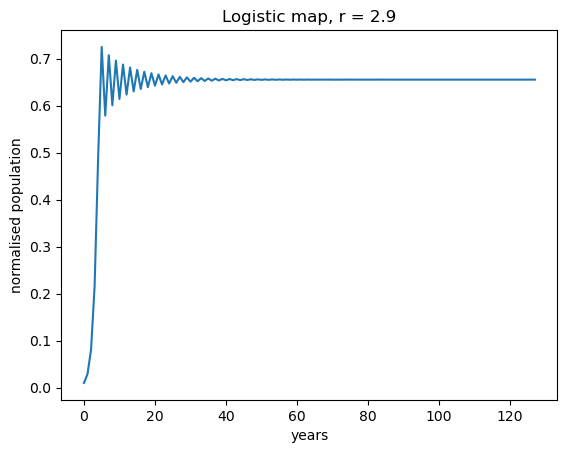

In [4]:
import matplotlib.pyplot as plt

r = 2.9
x = logistic_map_timeseries(x0=0.01, r=r, N=128)
plt.plot(x)
plt.xlabel('years')
plt.ylabel('normalised population')
plt.title('Logistic map, r = {}'.format(r))

Hold on, for $r = 2.9$ this is not a chaotic system! Try other values of $r$

- $r=1$ (first appearance of a non-zero stable population, or "fixed point")
- $r=3$ (first appearance of a population oscillating between two values, or "2-cycle")
- $r=1+\sqrt{6}$ (2-cycle goes unstable, and becomes a stable 4-cycle)
- $r=3.54409$... (4-cycle goes unstable, and becomes a stable 8-cycle)
- $r=3.569946$... (period becomes infinite -- non-repeating)
- $r=1+\sqrt{8}$ (stable 3-cycle appears out of chaos)

In each case, try varying $r$ from just below to just above the critical number to see how the behaviour changes. A qualitative change in system behaviour through an infinitesimal change to a parameters is called a "bifurcation". 

Philosophical question: you can predict numerically exactly (almost, within machine precision, anyway) how the logistic map behaves for various settings of $x_0$ and the $r$ parameter, but have you "understood" it? 

### Sensitivity to initial conditions

In [5]:
# similar to before but now it accepts x0 to be a vector
def logistic_map_ensemble(x0, r, N):
    x = np.zeros((N, len(x0)))             # allocate matrix of dimensions time x ensemble
    x[0, :] = x0                           # store initial conditions vector
    for i in range(N-1):
        x[i+1, :] = logistic_map(x[i], r)

    return x

Choose a set of initial conditions with small perturbations

In [6]:
x0 = 0.01 + 0.0001 * np.random.rand(8)
x0

array([0.01004162, 0.01009691, 0.01008373, 0.0100581 , 0.01006271,
       0.01008363, 0.01005431, 0.01001377])

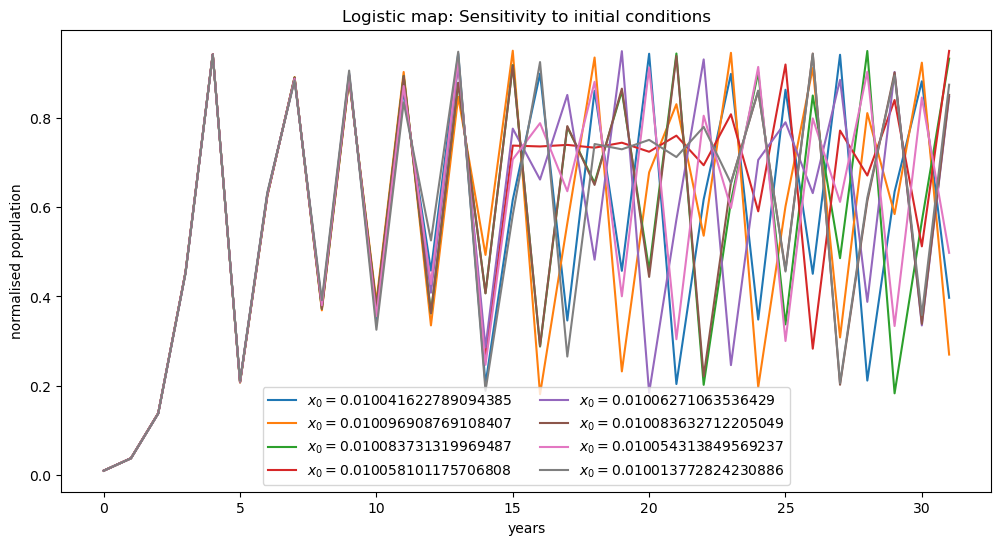

In [7]:
# create ensemble (x is now a matrix)
x = logistic_map_ensemble(x0, r = 3.8, N = 32)

# visualise it
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plt.plot(x, label=[r'$x_0 = ${}'.format(x0i) for x0i in x0])
plt.xlabel('years')
plt.ylabel('normalised population')
plt.title('Logistic map: Sensitivity to initial conditions')
plt.legend(ncols=2, )

Although all initial conditions start really close to another, their distance to another increases (exponentially?) and they quickly diverge into independent time series, losing the information of an (almost) common initial condition. Nevertheless these timeseries are here statistically still very similar as they still a solution to the same dynamical system!

### Period doubling

A 2-cycle sequence should have power spectrum at one given frequency $\omega = 1/2$ years $^{-1}$. A 4-cycle sequence would half the frequency (double the period) and so on. A chaotic sequence should therefore have some power at very low frequencies too! Let's test this hypothesis. Create a long time series

Text(0.5, 1.0, 'Power spectrum logistic map, r = 3.1')

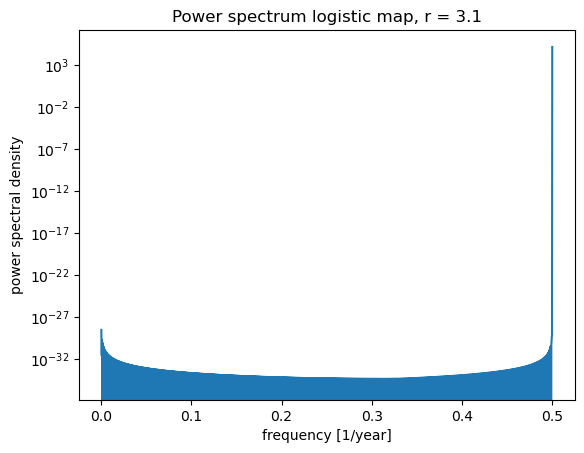

In [8]:
r = 3.1

# create a long time series, cut off the beginning and normalize
x = logistic_map_timeseries(x0=0.01, r=r, N=4096)
x_normalised = x[256:] - np.mean(x[256:])

# compute the power spectrum
ω = np.fft.rfftfreq(len(x_normalised), d=1)    # sample spacing (1 per year)
power = np.abs(np.fft.rfft(x_normalised))**2   # power = 

# visualise on a log-log plot
plt.semilogy(ω[1:], power[1:])
plt.xlabel('frequency [1/year]')
plt.ylabel('power spectral density')
plt.title('Power spectrum logistic map, r = {}'.format(r))

Every time the system undergoes a transition from one period length to another (the doubling) depending on the parameter $r$ we call a _bifurcation_ (point). One can create a more systematic bifurcation diagram (which we will do later) that nicely visualises these bifurcations. Here in the power spectrum you will just see more and more peaks popping up as periods get longer (but note that different superpositions of harmonics may mean that the Fourier transform has more than one peak of a longer period).

## A geometric approach: The Cobweb plot

To generate chaotic variability we need a (coupled) differential equation of 3 variables at least, so how can it emerge from a 1D discrete map?

The answer is that budworm population growth in a given season depends on how much they ate the preceding season, introducing a memory that allows it to behave in ways a continuous 1D differential equation cannot.

So it helps to think in terms of 6-month intervals, with the population $x_i$in the second six months of year $i$ carried over to the first six months of year $i+1$: no change in population over the "winter", but also no replenishment of food supply.

It also helps to define a logistic function
$$ f(x) = r x (1-x)$$
so the population after 2, 3 etc. years is:
$$ f^2(x) = f(f(x)) \; ; \; f^3(x) =  f(f(f(x)))$$

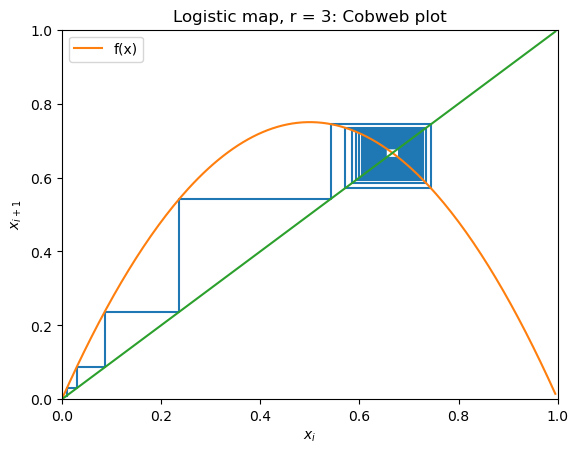

In [9]:
r = 3
x = logistic_map_timeseries(x0=0.01, r=r, N=256)
xx = np.repeat(x, 2)      # repeat x values to reuse i+1 for i in the next year
plt.plot(xx[:-1], xx[1:]) # plot in a staggered way to create cobweb "walking"

# add a line and quadratic curve following r
xs = np.arange(0, 1, 0.005)
plt.plot(xs, logistic_map(xs, r=r), label='f(x)')
plt.plot(xs, xs)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r'$x_i$')
plt.ylabel(r'$x_{i+1}$')
plt.title('Logistic map, r = {}: Cobweb plot'.format(r))
plt.legend()

In the Cobweb plot you start on the x axis with $x_i$ which is projected following the orange quadratic (the right-hand side of the logistic map) onto the yaxis for $x_{i+1}$. As $x_{i+1}$ becomes the new $x_i$, you walk back from the quadratic to the green diagonal and repeat the steps. A periodic solution of period 2 will bounce around in a rectangle, a period of 4 consists of 2 rectangles and so on. A chaotic solution will fill the plane densely.

## Folding

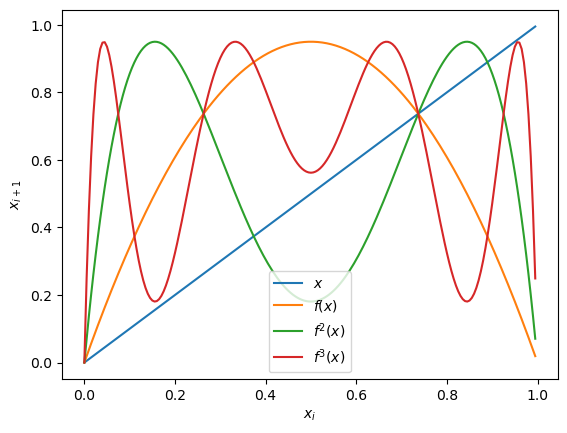

In [10]:
r = 3.8
xs = np.arange(0, 1, 0.005)

def f(x):
    return logistic_map(x, r=r)

plt.plot(xs, xs, label=r'$x$')
plt.plot(xs, f(xs), label=r'$f(x)$')
plt.plot(xs, f(f(xs)), label=r'$f^2(x)$')
plt.plot(xs, f(f(f(xs))), label=r'$f^3(x)$')
# plt.plot(xs, f(f(f(f(xs)))), label=r'$f^4(x)$')

plt.xlabel(r'$x_i$')
plt.ylabel(r'$x_{i+1}$')
plt.legend(loc=8)

So every iteration of the map will fold regions back onto itself. This is a common geometric thinking of chaotic dynamical systems leading to dense attractors.

#### Before you get too excited...

The logistic map was revolutionary for mathematical biologists, because it showed how you didn't need random shocks from external drivers to get highly unpredictable, random-looking behaviour. 

But this doesn't mean that random shocks can't give unpredictable, random-looking behaviour: in fact, most often when you see a series that looks random, it just is just that.

So we will devote a couple of lectures to simple linear stochastic processes, and how you can distinguish these from low-dimensional chaos.

## Objectives

This lecture course will cover some basic phenomenology and concepts behind chaos, random processes and the origins of predictability (or lack thereof) in physical systems. Our aims are:

- to give you some idea of how apparently unpredictable behaviour can arise in relatively simple dynamical systems,

- to demonstrate how geometrical tools can be used to understand the behaviour of such systems even when the underlying equations are impossible to solve explicitly,

- to introduce you to elementary stochastic processes and explain how these can be distinguished from low-order chaotic motion, including the concept of fractal dimension,

- to describe how local predictability can be assessed and exploited in practical forecasting a chaotic system,

- to get comfortable moving ambidextrously between numerical and analytic approaches to modelling, predicting and understanding physical systems.

## Philosophy

Throughout this course, we’ll be emphasizing the importance of non-linearity for real physical systems: almost all of the systems you deal with in the entire Oxford Physics course are linear, which makes analytic solutions tractable. We focus on analytically tractable cases because that's the best way of really understanding the fundamentals -- and because that's how your exams work.

But most of the systems you will deal with after Finals are non-linear: this makes them difficult to model analytically, but often quite straightforward to model numerically. But the analytic tools we will tell you about in this course are essential to understanding your numerical solutions: being able to simulate, and even predict, a system does not mean you have understood it.

The course is examined conventionally, using special cases carefully constructed to be solved with pen, paper and a calculator. You won't need to use Python in the exam, but you won't get nearly as much out of the course without it.

## Lecture outline

Lectures will be given live in the Lindemann (Wed) and Martin Wood (Thu and Fri) theatres. They will be recorded as usual, but we very strongly recommend you to attend in person. We will run a Python trouble-shooting session on Thursday, Week 1, 10-11am. Please attend this even if you are already fluent in Python, because we will be relying on you to help your peers get started.

- Wednesdays 11-12am, Lindemann Lecture Theatre
- Thursdays 9-10am, Martin Wood Lecture Theatre
- Fridays 12-1pm, Martin Wood Lecture Theatre


1. __Week 1 Wed: Introduction__ (Milan)
2. __Week 1 Thu: One-dimensional flows in phase space: a geometric approach, and getting going with Python__ (Milan)
3. __Week 1 Fri: Chaos, number theory and quantum mechanics__ (Tim Palmer, Guest lecture)
4. __Week 2 Wed: One-dimensional flows: bifurcations__ (Myles)
5. __Week 2 Thu: Two-dimensional flows: phase portraits, fixed points and the Jacobian__ (Myles)
6. __Week 2 Fri: Two-dimensional flows: limit cycles, control parameters and bifurcations__ (Myles)
7. __Week 3 Wed: Three-dimensional flows: the Lorenz equations, chaos and strange attractors__ (Myles)
8. __Week 3 Thu: Chaos in maps__ (Milan)
9. __Week 3 Fri: Introduction to stochastic processes: linear models, autocovariance and the power spectrum__ (Milan)
10. __Week 4 Wed: Distinguishing low-dimensional chaos from a linear stochastic processes: fractal dimension__ (Milan)
11. __Week 4 Thu: Local predictability of chaotic systems: understanding the Jacobian__ (Myles)
12. __Week 4 Fri: Global dynamics of error growth, stretching and folding, magic filo pastry, Lyapunov exponents and the Kaplan-Yorke conjecture__ (Myles)